In [44]:
# Cell 1: Importing libraries
import numpy as np
import matplotlib.pyplot as plt


In [45]:
# Cell 2: Define file paths
dbns_file = "forces/0/forceCoeffs.dat"
dbns_file_e = "forceCoeffs_eulerTime.dat"
exp_file = "reference_data.dat"
output_pdf_cn = "alpha_vs_Cn.pdf"
output_pdf_cm = "alpha_vs_Cm.pdf"

In [46]:
# Cell 3: Load DBNS simulation data
t_list, Cm_list, Cd_list, Cl_list = [], [], [], []

with open(dbns_file, 'r') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        parts = line.strip().split()
        if len(parts) < 4:
            continue
        t_list.append(float(parts[0]))
        Cd_list.append(float(parts[1]))
        Cl_list.append(float(parts[2]))
        Cm_list.append(float(parts[3]))

t = np.array(t_list)
Cd = np.array(Cd_list)
Cl = np.array(Cl_list)
Cm = np.array(Cm_list)


In [47]:
# Cell 3: Load DBNS simulation data
t_list_e, Cm_list_e, Cd_list_e, Cl_list_e = [], [], [], []

with open(dbns_file_e, 'r') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        parts = line.strip().split()
        if len(parts) < 4:
            continue
        t_list_e.append(float(parts[0]))
        Cd_list_e.append(float(parts[1]))
        Cl_list_e.append(float(parts[2]))
        Cm_list_e.append(float(parts[3]))

t_e = np.array(t_list_e)
Cd_e = np.array(Cd_list_e)
Cl_e = np.array(Cl_list_e)
Cm_e = np.array(Cm_list_e)


In [48]:
# Cell 4: Compute alpha and Cn for DBNS
alpha_deg = 0.016 - 2.51 * np.sin(39.978 * t)
alpha_deg_e = 0.016 - 2.51 * np.sin(39.978 * t_e)
alpha_deg_cm = 0.016 + 2.51 * np.sin(39.978 * t)
alpha_deg_cm_e = 0.016 + 2.51 * np.sin(39.978 * t_e)
alpha_rad = np.deg2rad(alpha_deg)
alpha_rad_e = np.deg2rad(alpha_deg_e)
Cn = Cd * np.sin(alpha_rad) + Cl * np.cos(alpha_rad)
Cn_e = Cd_e * np.sin(alpha_rad_e) + Cl_e * np.cos(alpha_rad_e)



In [49]:
# Cell 5: Load experimental data (alpha, Cn, Cm)
alpha_exp, Cn_exp, Cm_exp = [], [], []

with open(exp_file, 'r') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        Cm_exp.append(float(parts[2]))      # Column 3 = Cm
        alpha_exp.append(float(parts[4]))   # Column 5 = alpha
        Cn_exp.append(float(parts[6]))      # Column 7 = Cn

alpha_exp = np.array(alpha_exp)
Cn_exp = np.array(Cn_exp)
Cm_exp = np.array(Cm_exp)


Alpha vs Cn plot saved to alpha_vs_Cn.pdf


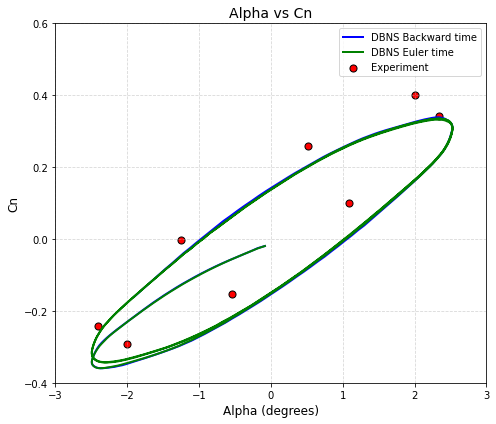

In [50]:

# Cell 6: Plot Alpha vs Cn

# Number of initial rows to skip
start_row = 100  # change this to the desired starting row number (0-based)

# Apply slicing to DBNS arrays
# alpha_deg = alpha_deg[start_row:]
# alpha_deg_e = alpha_deg_e[start_row:]
# Cn = Cn[start_row:]
# Cn_e = Cn_e[start_row:]



plt.figure(figsize=(7, 6))
plt.plot(alpha_deg, Cn, label='DBNS Backward time', color='blue', linewidth=2)
plt.plot(alpha_deg_e, Cn_e, label='DBNS Euler time', color='green', linewidth=2)
plt.scatter(alpha_exp, Cn_exp, label='Experiment', color='red', edgecolors='black', s=50)

plt.title("Alpha vs Cn", fontsize=14)
plt.xlabel("Alpha (degrees)", fontsize=12)
plt.ylabel("Cn", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([-3, 3])
plt.ylim([-0.4, 0.6])
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(output_pdf_cn)
print(f"Alpha vs Cn plot saved to {output_pdf_cn}")


Alpha vs Cm plot saved to alpha_vs_Cm.pdf


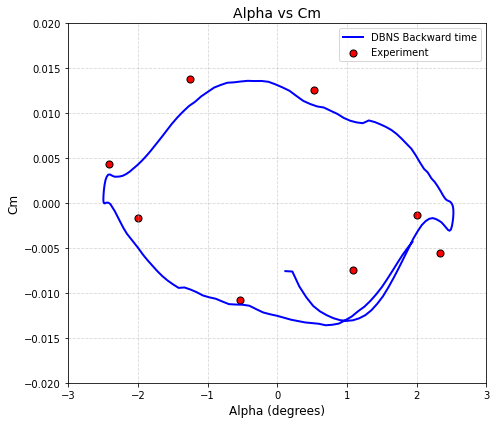

In [51]:
# Number of initial rows to skip
start_row = 100  # change this to the desired starting row number (0-based)

# Apply slicing to DBNS arrays
# t = t[start_row:]
# Cm = Cm[start_row:]
# Cm_e = Cm_e[start_row:]
# alpha_deg_cm = alpha_deg_cm[start_row:]
# alpha_deg_cm_e = alpha_deg_cm_e[start_row:]


# Cell 7: Plot Alpha vs Cm
plt.figure(figsize=(7, 6))
plt.plot(alpha_deg_cm, Cm, label='DBNS Backward time', color='blue', linewidth=2)
# plt.plot(alpha_deg_cm_e, Cm_e, label='DBNS Euler time', color='green', linewidth=2)
plt.scatter(alpha_exp, Cm_exp, label='Experiment', color='red', edgecolors='black', s=50)

plt.title("Alpha vs Cm", fontsize=14)
plt.xlabel("Alpha (degrees)", fontsize=12)
plt.ylabel("Cm", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([-3, 3])
plt.ylim([-0.02, 0.02])  # Adjust as needed
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(output_pdf_cm)
print(f"Alpha vs Cm plot saved to {output_pdf_cm}")
